## import packages

In [3]:
import numpy as np 
import scipy as sp 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Firing rate function

First we define and plot the firing rate function
$$\sigma(x) = \frac{1}{1+\exp(-a(x-h))}$$

In [4]:
def sigmoid(x,h,a):
    return 1/(1+np.exp(-a*(x-h)))

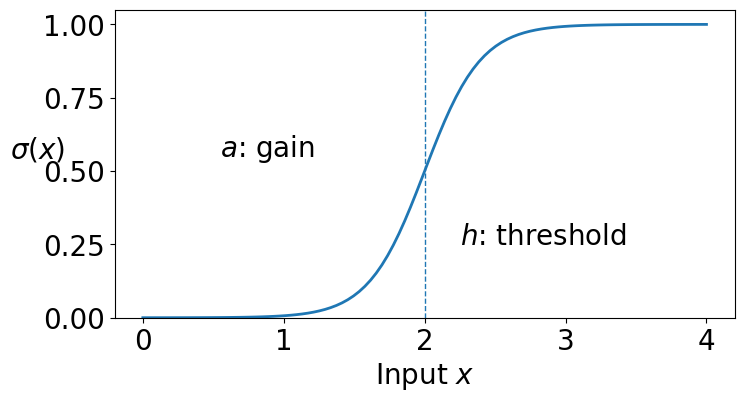

In [10]:
sz=20 ## for font sizes
x = np.linspace(0, 4, 100)
plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid(x, a=5, h=2), linewidth=2)
plt.axvline(2, linestyle="--", linewidth=1)
plt.xlabel(r"Input $x$", fontsize=sz)
plt.ylabel(r"$\sigma(x)$", rotation=False, fontsize=sz)
# plt.title(r"Sigmoidal firing rate: $f(x)=\frac{1}{1+\exp[-a(x-h)]}$")
plt.text(2.25, 0.25, r"$h$: threshold", size=sz)
plt.text(0.55, 0.55, r"$a$: gain", size=sz)
plt.ylim(0, 1.05)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Single population firing rate model

In this section, we study the single population firing rate model
$$ \tau \frac{{\rm d}r}{{\rm d}t}=-r+f(wr+I) $$

To simulate the model, we need to define a function for the right hand side of the differential equation

In [17]:
def drdt(t,x,h,a,w,I,tau):
    return (-x + sigmoid(w*x+I,h,a))/tau

In [18]:
t_final = 10
sol = solve_ivp(drdt, [0,t_final], [0], args=(1,1,0.5,2,1), dense_output=True)
t = np.linspace(0,t_final,1000)
r = sol.sol(t)

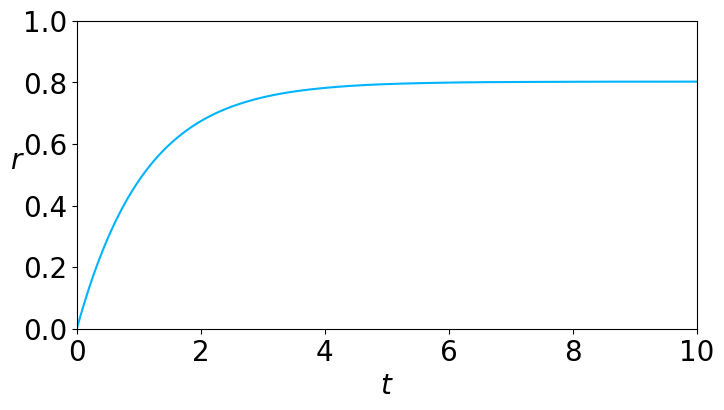

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(t,r[0],linewidth=1.5, color=[0,0.7,1])
plt.axis([0,10,0,1])
plt.xlabel('$t$', fontsize=sz)
plt.ylabel('$r$',rotation=False, fontsize=sz)
plt.tick_params(axis='both', which='major', labelsize=sz)

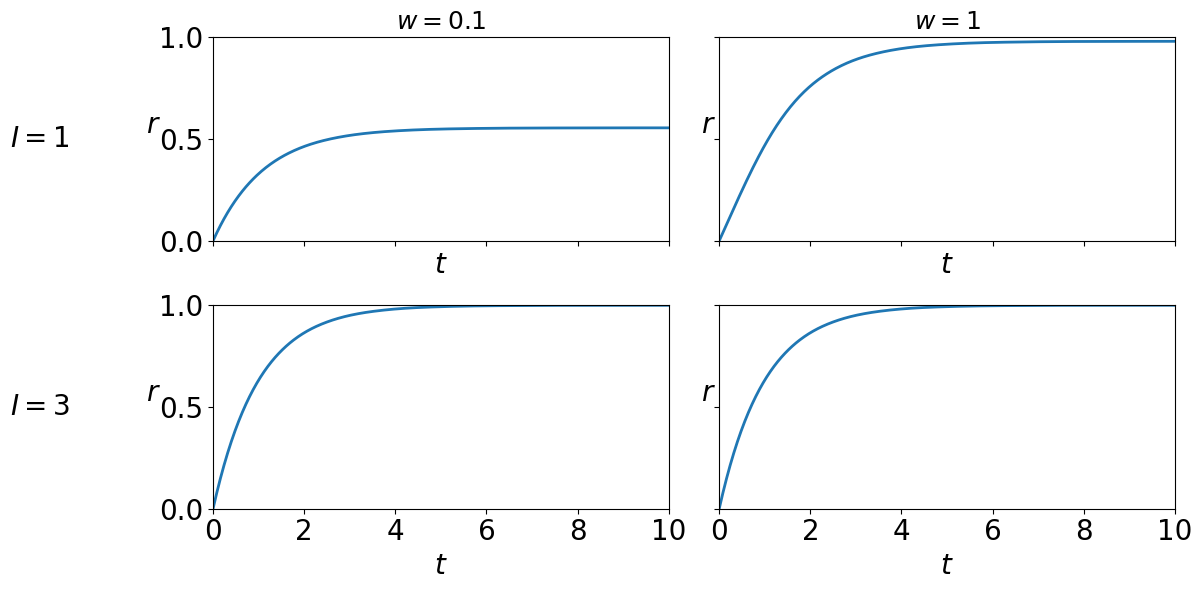

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f(x, h, a):
    return 1 / (1 + np.exp(-a * (x - h)))

def drdt(t, x, h, a, w, I, tau):
    return (-x + f(w*x + I, h, a)) / tau

# Parameters
h = 1
a = 4
tau = 1
x0 = [0.0]

t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)

I_values = [1, 3]
w_values = [0.1, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for i, I in enumerate(I_values):
    for j, w in enumerate(w_values):

        sol = solve_ivp(
            drdt,
            t_span,
            x0,
            t_eval=t_eval,
            args=(h, a, w, I, tau)
        )

        ax = axes[i, j]
        ax.plot(sol.t, sol.y[0], linewidth=2)

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 1)

        ax.set_xlabel(r"$t$", fontsize=sz)
        ax.set_ylabel(r"$r$", fontsize=sz, rotation=False)
        ax.tick_params(axis='both', which='major', labelsize=sz)

        if i == 0:
            ax.set_title(rf"$w={w}$", fontsize=18)

        if j == 0:
            ax.text(
                -0.38, 0.5, rf"$I={I}$",
                transform=ax.transAxes,
                fontsize=sz,
                va="center",
                ha="center"
            )

plt.tight_layout()

## Wilson-Cowan model

A two population firing rate/neural mass model
$$\tau_E\frac{{\rm d}E}{{\rm d}t} = - E + f(w_{EE}E+w_{IE}I+P)$$
$$\tau_I\frac{{\rm d}I}{{\rm d}t} = - I +f(w_{EI}E+w_{II}I+Q)$$


In [86]:
def WC(t,x,w,tau,P,h,a):
    
    E = x[0]
    I = x[1]
    
    dE = (-E + f(w[0,0]*E+w[1,0]*I+P[0],h[0],a[0]))/tau[0]
    dI = (-I + f(w[0,1]*E+w[1,1]*I+P[1],h[1],a[1]))/tau[1]
    
    return [ dE, dI ]

In [87]:
w = np.array([[12,10],[-10,-3]])
tau = [3,10]
P = [1,0]
h = [2,4]
a = [2, 0.2]

t_final = 500

In [88]:
E0 = 0.1
I0 = 0.1

sol = solve_ivp(WC, [0,t_final], [E0,I0], args=(w,tau,P,h,a), dense_output=True, rtol=1e-8)
t = np.linspace(0,t_final,10000)
E = sol.sol(t)[0]
I = sol.sol(t)[1]

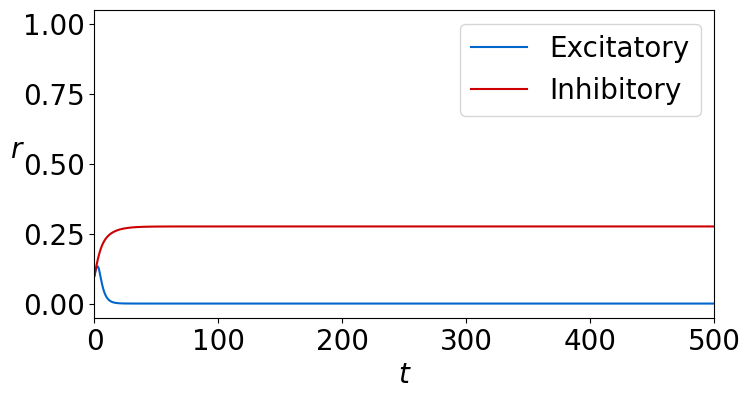

In [91]:
plt.figure(figsize=(8,4))

plt.plot(t,E,linewidth=1.5, color=[0,0.4,0.8], label='Excitatory')
plt.plot(t,I,linewidth=1.5, color=[0.8,0.0,0.0], label='Inhibitory')
    
plt.axis([0,500,-0.05,1.05])
plt.xlabel('$t$',fontsize=sz)
plt.ylabel('$r$',fontsize=sz, rotation=False)
plt.legend(loc='upper right', fontsize=sz)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Spiking neural model: Leaky Integrate and Fire model with spike resetting

Model is given by

$$
\tau_m \frac{dV}{dt} = -(V - V_{\rm rest}) + RI
$$

If $V \ge V_{\rm threshold}$, then $V \leftarrow V_{\rm reset}$

In [72]:
def lif_rhs(t, V, tau_m, V_rest, V_th, R, I):
    dVdt = (-(V[0] - V_rest) + R * I) / tau_m
    return [dVdt]


def threshold_event(t, V, tau_m, V_rest, V_th,  R, I):
    return V[0] - V_th


threshold_event.terminal = True
threshold_event.direction = 1


tau_m = 20.0
V_rest = -65.0
V_reset = -80.0
V_th = -60.0
R = 10.0
I = 2.5

t_start = 0.0
t_end = 200.0

current_t = t_start
current_V = [V_reset]

all_t = []
all_V = []
spike_times = []

while current_t < t_end:
    sol = solve_ivp(
        lif_rhs,
        [current_t, t_end],
        current_V,
        max_step=0.1,
        events=threshold_event,
        args=(tau_m, V_rest, V_th, R, I)
    )

    all_t.extend(sol.t)
    all_V.extend(sol.y[0])

    if sol.t_events[0].size > 0:
        spike_time = sol.t_events[0][0]
        spike_times.append(spike_time)

        current_t = spike_time
        current_V = [V_reset]

        all_t.append(current_t)
        all_V.append(V_reset)
    else:
        break

Spike times: [np.float64(13.862943611198931), np.float64(27.725887222397823), np.float64(41.588830833596724), np.float64(55.451774444795625), np.float64(69.31471805599452), np.float64(83.17766166719346), np.float64(97.0406052783924), np.float64(110.90354888959135), np.float64(124.76649250079029), np.float64(138.62943611198924), np.float64(152.49237972318818), np.float64(166.35532333438712), np.float64(180.21826694558607), np.float64(194.081210556785)]


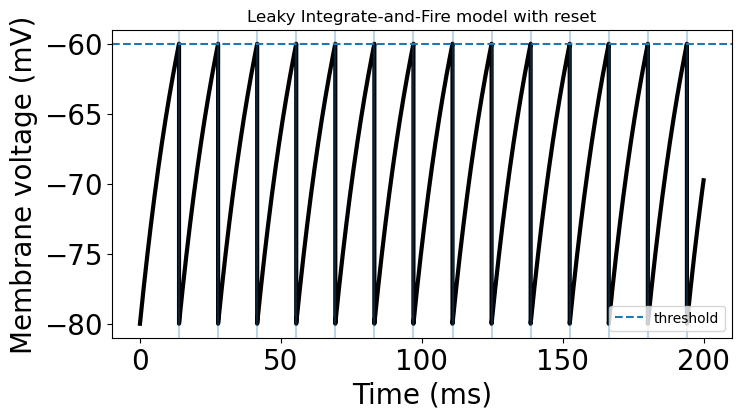

In [73]:
plt.figure(figsize=(8,4))
plt.plot(all_t, all_V, 'k-', lw=3)
plt.axhline(V_th, linestyle="--", label="threshold")

for spk in spike_times:
    plt.axvline(spk, alpha=0.3)

plt.xlabel("Time (ms)", fontsize=sz)
plt.ylabel("Membrane voltage (mV)", fontsize=sz)
plt.title("Leaky Integrate-and-Fire model with reset")
plt.legend()
plt.tick_params(axis='both', which='major', labelsize=sz)

print("Spike times:", spike_times)

## Fixed points and stability of rate model

### We use 

$$
\tau\frac{dr}{dt} = -r + \sigma(wr + I)
$$

In [21]:
from scipy.optimize import brentq

def sigma(x, a=3.0, theta=1.0):
    """
    Sigmoid activation function.

    a     : gain / steepness
    theta : threshold
    """
    return 1 / (1 + np.exp(-a * (x - theta)))


def dsigma(x, a=3.0, theta=1.0):
    """
    Derivative of the sigmoid activation function.
    """
    y = sigma(x, a=a, theta=theta)
    return a * y * (1 - y)


def drdt(t, r, tau, w, I, a, theta):
    """
    Rate model:
    
    tau dr/dt = -r + sigma(wr + I)
    """
    return (-r[0] + sigma(w * r[0] + I, a=a, theta=theta)) / tau

In [28]:
## parameters
tau = 10.0
w = 4.0
I = -1.0

a = 3.0
theta = 1.0

a=1
w=4
I=-1

In [29]:
## Find fixed points numerically

def fixed_point_equation(r, w, I, a, theta):
    return sigma(w * r + I, a=a, theta=theta) - r


r_grid = np.linspace(0, 1, 1000)

fixed_points = []

for k in range(len(r_grid) - 1):
    r_left = r_grid[k]
    r_right = r_grid[k + 1]

    f_left = fixed_point_equation(r_left, w, I, a, theta)
    f_right = fixed_point_equation(r_right, w, I, a, theta)

    if f_left * f_right < 0:
        root = brentq(
            fixed_point_equation,
            r_left,
            r_right,
            args=(w, I, a, theta)
        )
        fixed_points.append(root)

print("Fixed points:")
for fp in fixed_points:
    print(fp)

Fixed points:
0.4999999999168997


In [30]:
## check stability of each fixed point
def stability_derivative(r, tau, w, I, a, theta):
    return (-1 + w * dsigma(w * r + I, a=a, theta=theta)) / tau


print("Fixed point stability:")

for fp in fixed_points:
    slope = stability_derivative(fp, tau, w, I, a, theta)

    if slope < 0:
        stability = "stable"
    else:
        stability = "unstable"

    print(f"r* = {fp:.4f}, derivative = {slope:.4f}, {stability}")

Fixed point stability:
r* = 0.5000, derivative = 0.0000, unstable


## plot $r$ and $\sigma(wr+I)$

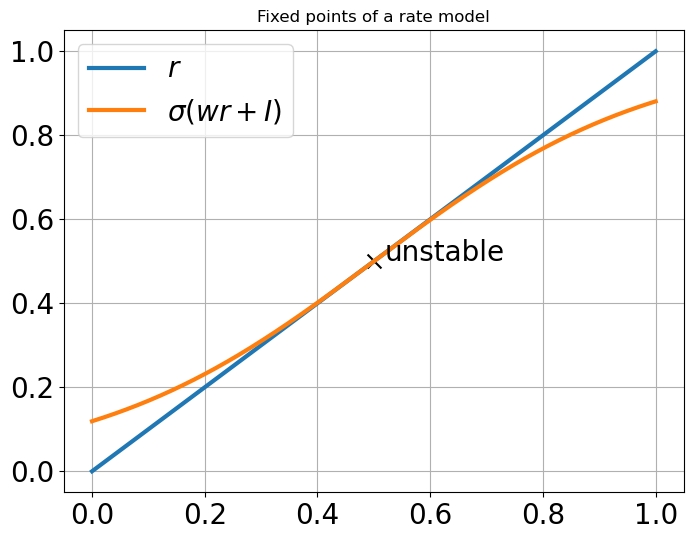

In [31]:
r_grid = np.linspace(0, 1, 1000)

current_activity = r_grid
generated_activity = sigma(w * r_grid + I, a=a, theta=theta)

plt.figure(figsize=(8, 6))

plt.plot(r_grid, current_activity, label=r"$r$", lw=3)
plt.plot(r_grid, generated_activity, label=r"$\sigma(wr + I)$", lw=3)

for fp in fixed_points:
    slope = stability_derivative(fp, tau, w, I, a, theta)

    if slope < 0:
        label = "stable"
        marker = "o"
    else:
        label = "unstable"
        marker = "x"

    plt.scatter(fp, fp, s=100, marker=marker, color='black')
    plt.text(fp + 0.02, fp, label, size=sz)

# plt.xlabel("Current activity, r")
# plt.ylabel("Generated activity")
plt.title("Fixed points of a rate model")
plt.legend(fontsize=sz)
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=sz)

## plot $\frac{dr}{dt}$ vs $r$

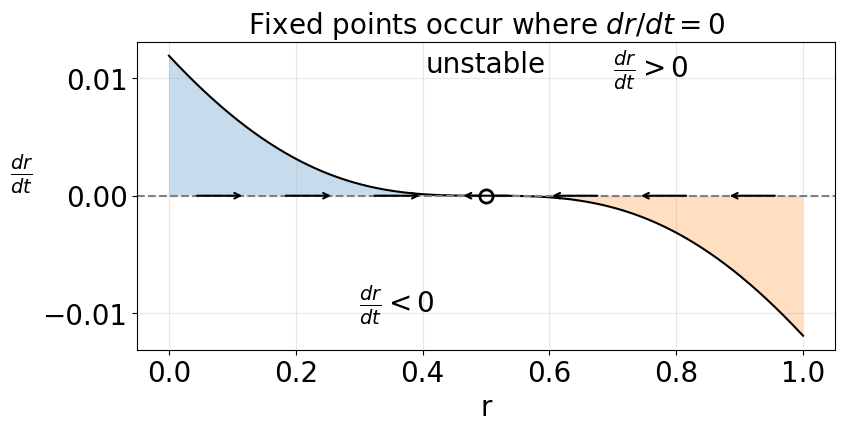

In [32]:
dr_values = (-r_grid + sigma(w * r_grid + I, a=a, theta=theta)) / tau

plt.figure(figsize=(9, 4))

plt.plot(r_grid, dr_values, color="black")
plt.axhline(0, linestyle="--", color="gray")

# Shade regions where dr/dt > 0 and dr/dt < 0
plt.fill_between(
    r_grid,
    0,
    dr_values,
    where=(dr_values > 0),
    alpha=0.25,
    interpolate=True,
    label=r"$dr/dt > 0$: activity increases"
)

plt.fill_between(
    r_grid,
    0,
    dr_values,
    where=(dr_values < 0),
    alpha=0.25,
    interpolate=True,
    label=r"$dr/dt < 0$: activity decreases"
)


for fp in fixed_points:
    # derivative of dr/dt with respect to r at the fixed point
    slope = (-1 + w * dsigma(w * fp + I, a=a, theta=theta)) / tau

    if slope < 0:
        # stable fixed point: filled black dot
        plt.scatter(fp, 0, s=90, color="black", zorder=3)
        plt.text(fp, 0.01, "stable", ha="center", va="bottom", fontsize=sz)
    else:
        # unstable fixed point: hollow black circle
        plt.scatter(fp, 0, s=90, facecolors="white", edgecolors="black", linewidths=2, zorder=3)
        plt.text(fp, 0.01, "unstable", ha="center", va="bottom", fontsize=sz)

for x0 in np.linspace(r_grid.min() + 0.08, r_grid.max() - 0.08, 7):
    value = (-x0 + sigma(w * x0 + I, a=a, theta=theta)) / tau

    if value > 0:
        # r increases, arrow points right
        plt.annotate(
            "",
            xy=(x0 + 0.04, 0),
            xytext=(x0 - 0.04, 0),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
        )
    else:
        # r decreases, arrow points left
        plt.annotate(
            "",
            xy=(x0 - 0.04, 0),
            xytext=(x0 + 0.04, 0),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
        )

plt.text(0.3, -0.01, r"$\frac{dr}{dt} < 0$", size=sz)
plt.text(0.7, 0.01, r"$\frac{dr}{dt} > 0$", size=sz)

plt.xlabel("r", fontsize=sz)
plt.ylabel(r"$\frac{dr}{dt}$", rotation=0, labelpad=15, fontsize=sz)
plt.title("Fixed points occur where $dr/dt = 0$", fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

### Fixed point and stability analysis of the WC model

In [33]:
from scipy.optimize import root

In [34]:
def sigma(x, a=3.0, theta=1.0):
    """
    Sigmoid activation function.
    
    a     : gain / steepness
    theta : threshold
    """
    return 1 / (1 + np.exp(-a * (x - theta)))


def dsigma(x, a=3.0, theta=1.0):
    """
    Derivative of the sigmoid activation function.
    """
    y = sigma(x, a=a, theta=theta)
    return a * y * (1 - y)

def wc_rhs(t, z, params):
    """
    Wilson-Cowan right-hand side.
    
    z[0] = E
    z[1] = I
    """
    E, I = z

    tau_E = params["tau_E"]
    tau_I = params["tau_I"]

    w_EE = params["w_EE"]
    w_EI = params["w_EI"]
    w_IE = params["w_IE"]
    w_II = params["w_II"]

    P = params["P"]
    Q = params["Q"]

    a = params["a"]
    theta = params["theta"]

    u_E = w_EE * E - w_EI * I + P
    u_I = w_IE * E - w_II * I + Q

    dE = (-E + sigma(u_E, a=a, theta=theta)) / tau_E
    dI = (-I + sigma(u_I, a=a, theta=theta)) / tau_I

    return np.array([dE, dI])

In [55]:
## choose parameter values

params = {
    "tau_E": 10.0,
    "tau_I": 20.0,

    "w_EE": 10.0,
    "w_EI": 12.0,
    "w_IE": 10.0,
    "w_II": 2.0,

    "P": 3,
    "Q": 0.0,

    "a": 3.0,
    "theta": 1.0
}

In [56]:
## find fixed points
def fixed_point_equations(z, params):
    """
    Fixed point equations:
    
    dE/dt = 0
    dI/dt = 0
    """
    return wc_rhs(0, z, params)

### We search from many initial guesses because the system may have multiple fixed points

In [57]:
def find_fixed_points(params, n_grid=9, tol=1e-8):
    """
    Find fixed points by using multiple initial guesses.
    """
    guesses = np.linspace(0, 1, n_grid)

    fixed_points = []

    for E0 in guesses:
        for I0 in guesses:
            sol = root(
                fixed_point_equations,
                x0=np.array([E0, I0]),
                args=(params,)
            )

            if sol.success:
                fp = sol.x

                # Keep only biologically relevant points in [0, 1] x [0, 1]
                if 0 <= fp[0] <= 1 and 0 <= fp[1] <= 1:

                    # Check if this fixed point is already found
                    is_new = True

                    for old_fp in fixed_points:
                        if np.linalg.norm(fp - old_fp) < tol:
                            is_new = False
                            break

                    if is_new:
                        fixed_points.append(fp)

    return fixed_points


fixed_points = find_fixed_points(params)

print("Fixed points:")
for fp in fixed_points:
    print(fp)

Fixed points:
[0.1447073  0.33660971]


In [58]:
## jacobian and stability

def wc_jacobian(E, I, params):
    """
    Jacobian matrix of the Wilson-Cowan system.
    """
    tau_E = params["tau_E"]
    tau_I = params["tau_I"]

    w_EE = params["w_EE"]
    w_EI = params["w_EI"]
    w_IE = params["w_IE"]
    w_II = params["w_II"]

    P = params["P"]
    Q = params["Q"]

    a = params["a"]
    theta = params["theta"]

    u_E = w_EE * E - w_EI * I + P
    u_I = w_IE * E - w_II * I + Q

    sE_prime = dsigma(u_E, a=a, theta=theta)
    sI_prime = dsigma(u_I, a=a, theta=theta)

    J = np.array([
        [(-1 + w_EE * sE_prime) / tau_E,
         (-w_EI * sE_prime) / tau_E],

        [(w_IE * sI_prime) / tau_I,
         (-1 - w_II * sI_prime) / tau_I]
    ])

    return J


def classify_fixed_point(E, I, params):
    """
    Classify fixed point using eigenvalues of the Jacobian.
    """
    J = wc_jacobian(E, I, params)
    eigenvalues = np.linalg.eigvals(J)

    real_parts = np.real(eigenvalues)

    if np.all(real_parts < 0):
        stability = "stable"
    elif np.any(real_parts > 0):
        stability = "unstable"
    else:
        stability = "borderline"

    return stability, eigenvalues

In [59]:
for fp in fixed_points:
    E_star, I_star = fp

    stability, eigenvalues = classify_fixed_point(E_star, I_star, params)

    print("-----------------------------")
    print(f"Fixed point: E* = {E_star:.4f}, I* = {I_star:.4f}")
    print("Eigenvalues:", eigenvalues)
    print("Stability:", stability)

-----------------------------
Fixed point: E* = 0.1447, I* = 0.3366
Eigenvalues: [0.0771551+0.33399179j 0.0771551-0.33399179j]
Stability: unstable


### Plot nullclines, vector field, and fixed points

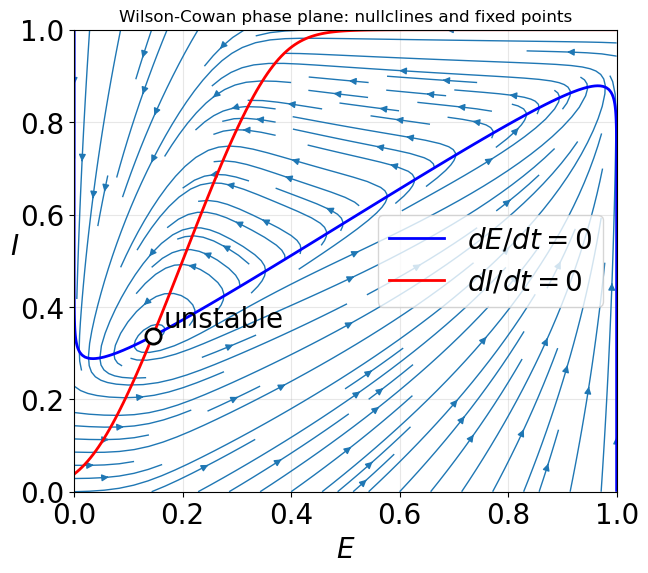

In [60]:
# Grid for phase plane
E_vals = np.linspace(0, 1, 200)
I_vals = np.linspace(0, 1, 200)

E_grid, I_grid = np.meshgrid(E_vals, I_vals)

dE_grid = np.zeros_like(E_grid)
dI_grid = np.zeros_like(I_grid)

for i in range(E_grid.shape[0]):
    for j in range(E_grid.shape[1]):
        dE, dI = wc_rhs(
            0,
            [E_grid[i, j], I_grid[i, j]],
            params
        )
        dE_grid[i, j] = dE
        dI_grid[i, j] = dI

plt.figure(figsize=(7, 6))

# Vector field
speed = np.sqrt(dE_grid**2 + dI_grid**2)

plt.streamplot(
    E_grid,
    I_grid,
    dE_grid,
    dI_grid,
    density=1.2,
    linewidth=1,
    arrowsize=1
)

# Nullclines
plt.contour(
    E_grid,
    I_grid,
    dE_grid,
    levels=[0],
    colors="blue",
    linewidths=2
)

plt.contour(
    E_grid,
    I_grid,
    dI_grid,
    levels=[0],
    colors="red",
    linewidths=2
)

# Fixed points
for fp in fixed_points:
    E_star, I_star = fp

    stability, eigenvalues = classify_fixed_point(E_star, I_star, params)

    if stability == "stable":
        # Stable = filled black dot
        plt.scatter(
            E_star,
            I_star,
            s=120,
            color="black",
            zorder=5
        )
        plt.text(
            E_star + 0.02,
            I_star + 0.02,
            "stable",
            fontsize=sz
        )
    else:
        # Unstable = hollow black circle
        plt.scatter(
            E_star,
            I_star,
            s=120,
            facecolors="white",
            edgecolors="black",
            linewidths=2,
            zorder=5
        )
        plt.text(
            E_star + 0.02,
            I_star + 0.02,
            "unstable",
            fontsize=sz
        )

plt.xlabel("$E$", size=sz)
plt.ylabel("$I$", rotation = 0, size=sz)
plt.title("Wilson-Cowan phase plane: nullclines and fixed points")

# Add legend manually
plt.plot([], [], color="blue", linewidth=2, label=r"$dE/dt = 0$")
plt.plot([], [], color="red", linewidth=2, label=r"$dI/dt = 0$")
plt.legend(fontsize=sz)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

### Plot trajectories from different initial conditions

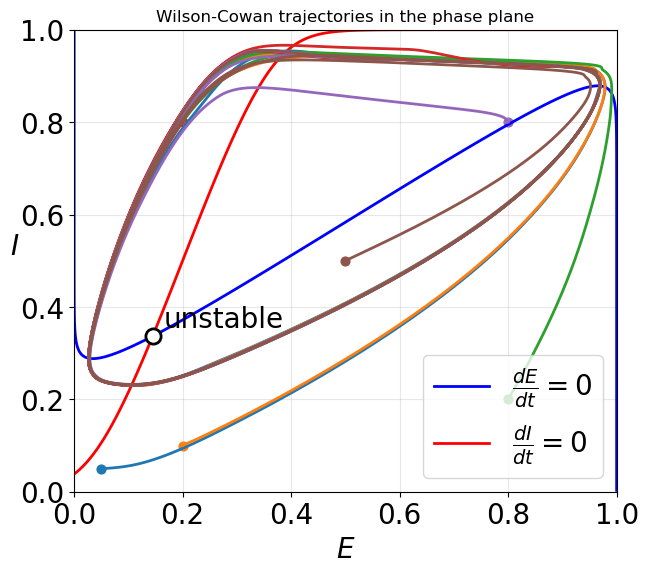

In [61]:
initial_conditions = [
    [0.05, 0.05],
    [0.2, 0.1],
    [0.8, 0.2],
    [0.2, 0.8],
    [0.8, 0.8],
    [0.5, 0.5]
]

t_eval = np.linspace(0, 300, 2000)

plt.figure(figsize=(7, 6))

# Plot nullclines again
plt.contour(
    E_grid,
    I_grid,
    dE_grid,
    levels=[0],
    colors="blue",
    linewidths=2
)

plt.contour(
    E_grid,
    I_grid,
    dI_grid,
    levels=[0],
    colors="red",
    linewidths=2
)

# Plot trajectories
for z0 in initial_conditions:
    sol = solve_ivp(
        wc_rhs,
        t_span=[0, 300],
        y0=z0,
        t_eval=t_eval,
        args=(params,)
    )

    plt.plot(sol.y[0], sol.y[1], linewidth=2)
    plt.scatter(z0[0], z0[1], s=40)

# Fixed points
for fp in fixed_points:
    E_star, I_star = fp

    stability, eigenvalues = classify_fixed_point(E_star, I_star, params)

    if stability == "stable":
        plt.scatter(E_star, I_star, s=120, color="black", zorder=5)
        plt.text(E_star + 0.02, I_star + 0.02, "stable", fontsize=sz)
    else:
        plt.scatter(
            E_star,
            I_star,
            s=120,
            facecolors="white",
            edgecolors="black",
            linewidths=2,
            zorder=5
        )
        plt.text(E_star + 0.02, I_star + 0.02, "unstable", fontsize=sz)

plt.xlabel("$E$", size=sz)
plt.ylabel("$I$", rotation=0, size=sz)
plt.title("Wilson-Cowan trajectories in the phase plane")

plt.plot([], [], color="blue", linewidth=2, label=r"$\frac{dE}{dt} = 0$")
plt.plot([], [], color="red", linewidth=2, label=r"$\frac{dI}{dt} = 0$")
plt.legend(fontsize=sz)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Single post synaptic rate model

### We simulate 

$$
\tau\frac{d\textbf{r}}{dt} = -\textbf{r} + \sigma(\textbf{w}\cdot \textbf{u})
$$

In [162]:
def sigma(x, a=3.0, theta=1.0):
    """
    Sigmoid activation function.

    a     : gain / steepness
    theta : threshold
    """
    return 1 / (1 + np.exp(-a * (x - theta)))

def presynaptic_activity(t):
    """
    Activity of 5 presynaptic neurons.
    """

    u1 = 0.6 + 0.3 * np.sin(2 * np.pi * t / 50)
    u2 = 0.4 + 0.2 * np.sin(2 * np.pi * t / 80)
    u3 = 0.5
    u4 = 0.3 + 0.2 * np.cos(2 * np.pi * t / 100)
    u5 = 0.2

    return np.array([u1, u2, u3, u4, u5])

In [163]:
## define the rate model
def rate_neuron_model(t, r, w, tau, a, theta):
    """
    Single postsynaptic firing-rate model.

    tau dr/dt = -r + sigma(w · u)

    r : postsynaptic activity
    w : vector of synaptic weights
    u : presynaptic activity vector
    """

    u = presynaptic_activity(t)

    weighted_input = np.dot(w, u)

    drdt = (-r[0] + sigma(weighted_input, a=a, theta=theta)) / tau

    return [drdt]

In [164]:
## parameters

# Synaptic weights from 5 presynaptic neurons
w = np.array([1.2, 0.8, -0.5, 1.0, -0.3])

# Time constant
tau = 10.0

# Sigmoid parameters
a = 3.0
theta = 1.0

# Initial postsynaptic activity
r0 = [0.1]

# Time interval
t_start = 0
t_end = 200
t_eval = np.linspace(t_start, t_end, 1000)

In [165]:
## simulate

sol = solve_ivp(
    rate_neuron_model,
    t_span=[t_start, t_end],
    y0=r0,
    t_eval=t_eval,
    args=(w, tau, a, theta)
)

t = sol.t
r = sol.y[0]

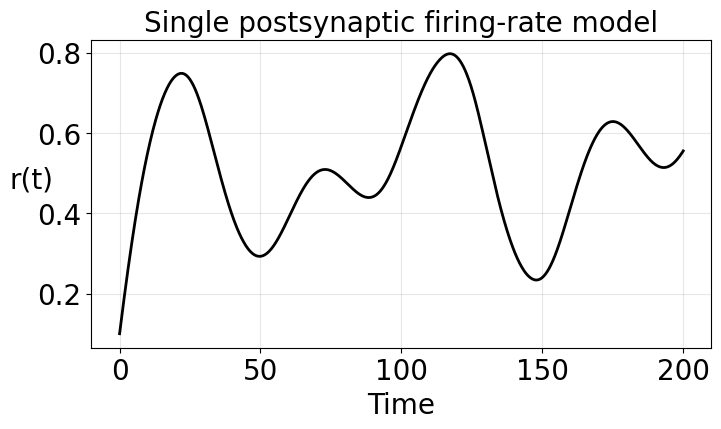

In [166]:
## plot
plt.figure(figsize=(8, 4))

plt.plot(t, r, color="black", linewidth=2)

plt.xlabel("Time", fontsize=sz)
plt.ylabel("r(t)", rotation=0, fontsize=sz)
plt.title("Single postsynaptic firing-rate model", fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

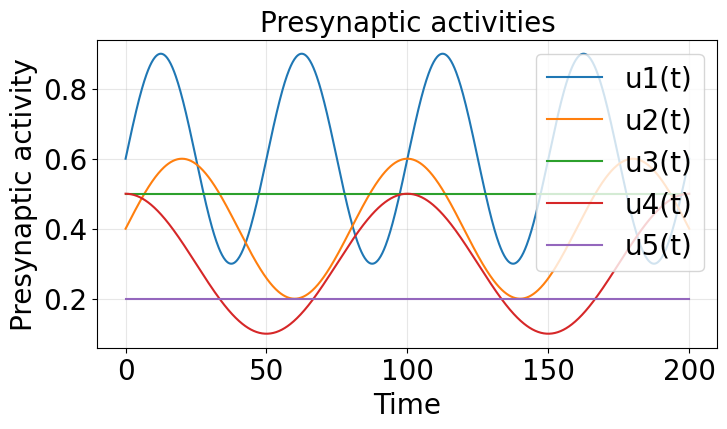

In [169]:
u_values = np.array([presynaptic_activity(tt) for tt in t])

plt.figure(figsize=(8, 4))

for j in range(u_values.shape[1]):
    plt.plot(t, u_values[:, j], label=f"u{j+1}(t)")

plt.xlabel("Time", fontsize=sz)
plt.ylabel("Presynaptic activity", fontsize=sz)
plt.title("Presynaptic activities", fontsize=sz)
plt.legend(fontsize=sz)
plt.grid(True, alpha=0.3)

plt.tick_params(axis='both', which='major', labelsize=sz)

## Spiking neural network of E/I LIF neurons

In [82]:
def simulate_lif_network(
    N=100,
    frac_E=0.8,
    T=500.0,
    dt=0.1,
    tau_m=20.0,
    V_rest=-65.0,
    V_reset=-65.0,
    V_th=-50.0,
    R=10.0,
    I_ext_mean=2.4,
    I_ext_std=0.2,
    p_connect=0.5,
    w_E=0.6,
    w_I=-2.0,
    seed=42
):
    rng = np.random.default_rng(seed)

    n_steps = int(T / dt)
    time = np.arange(n_steps) * dt

    N_E = int(frac_E * N)
    N_I = N - N_E

    # Connectivity matrix
    # W[i, j] = effect of neuron j on neuron i
    mask = rng.random((N, N)) < p_connect
    np.fill_diagonal(mask, False)

    W = np.zeros((N, N))

    # Excitatory presynaptic neurons have positive outgoing weights
    W[:, :N_E] = w_E

    # Inhibitory presynaptic neurons have negative outgoing weights
    W[:, N_E:] = w_I

    W = W * mask

    # External input current
    I_ext = rng.normal(I_ext_mean, I_ext_std, size=N)

    # Voltage
    V = np.zeros((N, n_steps))
    V[:, 0] = rng.normal(V_rest, 2.0, size=N)

    # Spike matrix
    spikes = np.zeros((N, n_steps), dtype=int)

    # Recurrent synaptic input
    syn_input = np.zeros(N)

    for k in range(1, n_steps):

        # Total input current
        I_total = I_ext + syn_input

        # LIF voltage update
        dVdt = (-(V[:, k-1] - V_rest) + R * I_total) / tau_m

        V[:, k] = V[:, k-1] + dt * dVdt

        # Threshold crossing
        spiking_neurons = V[:, k] >= V_th

        # Record spikes
        spikes[spiking_neurons, k] = 1

        # Reset after spike
        V[spiking_neurons, k] = V_reset

        # Recurrent input from spikes at this time step
        syn_input = W @ spikes[:, k]

    return time, V, spikes, W, N_E

In [83]:
time, V, spikes, W, N_E = simulate_lif_network(
    N=100,
    T=500,
    dt=0.1,
    R=10.0,
    I_ext_mean=1.2,
    I_ext_std=0.2,
    w_E=0.6,
    w_I=-2.0,
    seed=1
)

print("Total spikes:", spikes.sum())
print("Mean firing rate:", spikes.sum() / (100 * (500 / 1000)), "Hz")
print("Maximum voltage:", V.max())

Total spikes: 34
Mean firing rate: 0.68 Hz
Maximum voltage: -50.00000128351809


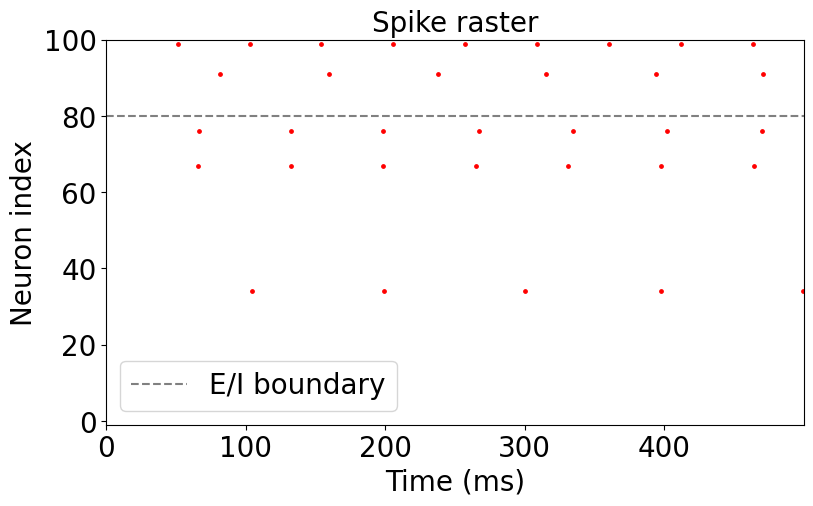

In [84]:
def plot_raster(time, spikes, N_E=None):
    neuron_ids, spike_time_ids = np.where(spikes == 1)

    plt.figure(figsize=(9, 5))

    if len(spike_time_ids) > 0:
        spike_times = time[spike_time_ids]

        plt.scatter(
            spike_times,
            neuron_ids,
            s=6,
            color="red"
        )
    else:
        plt.text(
            0.5,
            0.5,
            "No spikes",
            ha="center",
            va="center",
            transform=plt.gca().transAxes,
            fontsize=16
        )

    if N_E is not None:
        plt.axhline(
            N_E,
            linestyle="--",
            color="gray",
            label="E/I boundary"
        )
        plt.legend(fontsize=sz)

    plt.xlim(time[0], time[-1])
    plt.ylim(-1, spikes.shape[0])

    plt.xlabel("Time (ms)", fontsize=sz)
    plt.ylabel("Neuron index", fontsize=sz)
    plt.title("Spike raster", fontsize=sz)


plot_raster(time, spikes, N_E=N_E)
plt.tick_params(axis='both', which='major', labelsize=sz)

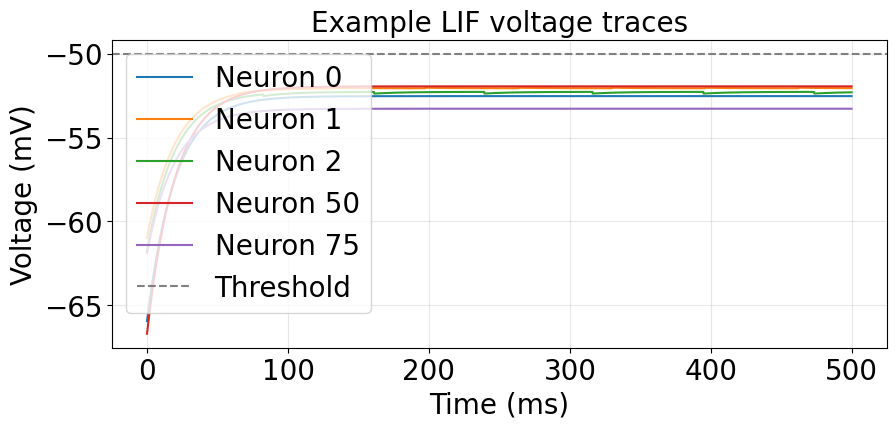

In [81]:
## voltage traces

plt.figure(figsize=(10, 4))

for idx in [0, 1, 2, 50, 75]:
    plt.plot(time, V[idx], label=f"Neuron {idx}")

plt.axhline(-50, linestyle="--", color="gray", label="Threshold")

plt.xlabel("Time (ms)", fontsize=sz)
plt.ylabel("Voltage (mV)", fontsize=sz)
plt.title("Example LIF voltage traces", fontsize=sz)
plt.legend(fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

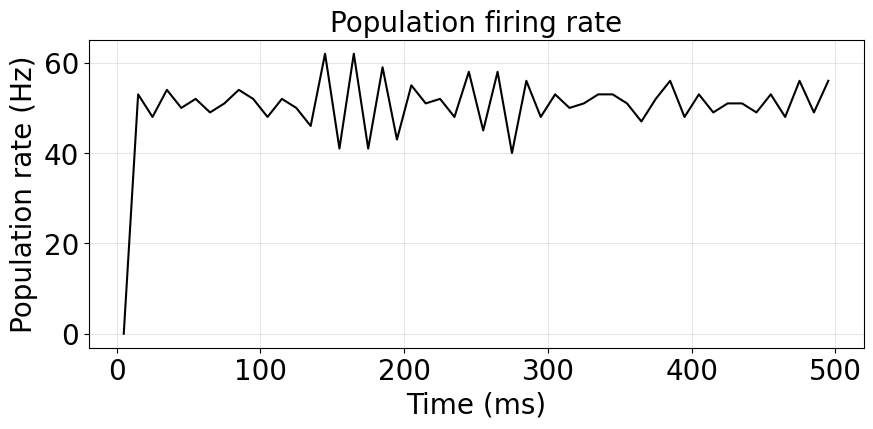

In [183]:
## population firing rate
def compute_population_rate(spikes, dt, bin_size=10.0):
    N, n_steps = spikes.shape

    steps_per_bin = int(bin_size / dt)
    n_bins = n_steps // steps_per_bin

    rates = []
    rate_times = []

    for b in range(n_bins):
        start = b * steps_per_bin
        end = (b + 1) * steps_per_bin

        spike_count = spikes[:, start:end].sum()

        # Convert bin duration from ms to seconds
        rate = spike_count / (N * (bin_size / 1000))

        rates.append(rate)
        rate_times.append((start + end) * dt / 2)

    return np.array(rate_times), np.array(rates)


rate_times, pop_rate = compute_population_rate(spikes, dt=0.1, bin_size=10.0)

plt.figure(figsize=(10, 4))

plt.plot(rate_times, pop_rate, color="black")

plt.xlabel("Time (ms)", fontsize=sz)
plt.ylabel("Population rate (Hz)", fontsize=sz)
plt.title("Population firing rate", fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Different firing regimes

Silent / weak input
Mean firing rate: 0.66 Hz
Irregular activity
Mean firing rate: 35.2 Hz
Strong excitation
Mean firing rate: 72.2 Hz


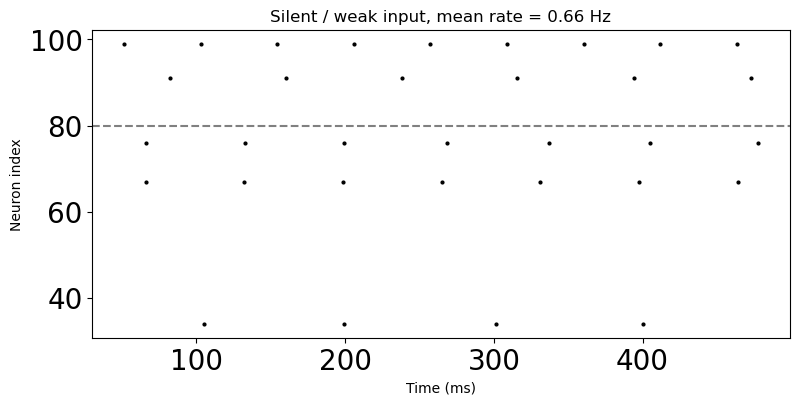

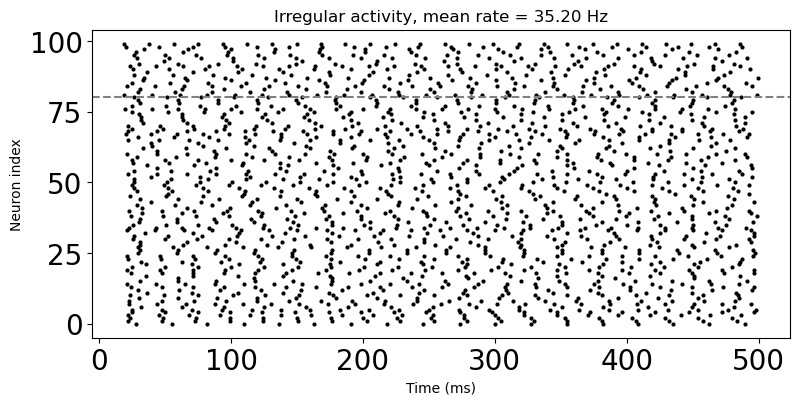

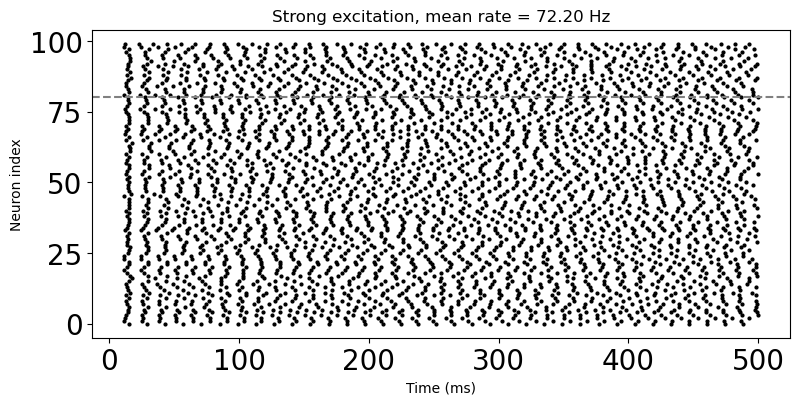

In [85]:
regimes = {
    "Silent / weak input": {
        "I_ext_mean": 1.2,
        "w_E": 0.5,
        "w_I": -2.5
    },
    "Irregular activity": {
        "I_ext_mean": 2,
        "w_E": 0.7,
        "w_I": -2.5
    },
    "Strong excitation": {
        "I_ext_mean": 2.8,
        "w_E": 1.2,
        "w_I": -1.5
    }
}

for name, pars in regimes.items():

    time, V, spikes, W, N_E = simulate_lif_network(
        N=100,
        T=500,
        dt=0.1,
        R=10,
        I_ext_mean=pars["I_ext_mean"],
        w_E=pars["w_E"],
        w_I=pars["w_I"],
        seed=1
    )

    mean_rate = spikes.sum() / (100 * (500 / 1000))

    print(name)
    print("Mean firing rate:", mean_rate, "Hz")

    neuron_ids, spike_time_ids = np.where(spikes == 1)
    spike_times = time[spike_time_ids]

    plt.figure(figsize=(9, 4))
    plt.scatter(spike_times, neuron_ids, s=4, color="black")
    plt.axhline(N_E, linestyle="--", color="gray")
    plt.xlabel("Time (ms)")
    plt.ylabel("Neuron index")
    plt.title(f"{name}, mean rate = {mean_rate:.2f} Hz")
    plt.tick_params(axis='both', which='major', labelsize=sz)

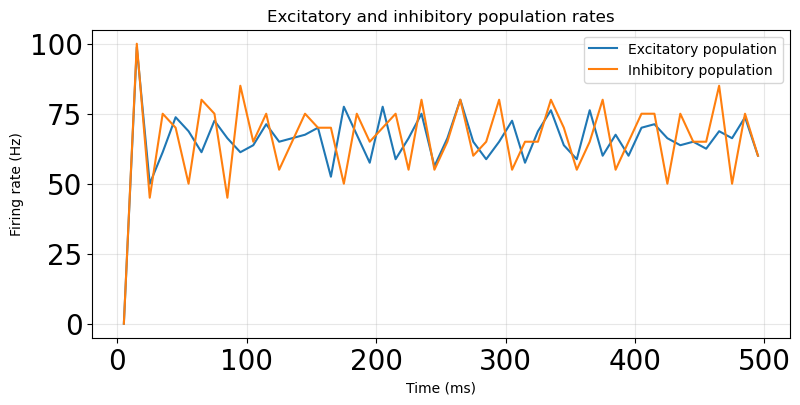

In [203]:
## compare excitatory and inhibitory firing rates

def compute_group_rate(spikes, neuron_indices, dt, bin_size=10.0):
    group_spikes = spikes[neuron_indices]

    N_group = len(neuron_indices)
    n_steps = group_spikes.shape[1]

    steps_per_bin = int(bin_size / dt)
    n_bins = n_steps // steps_per_bin

    rates = []
    times = []

    for b in range(n_bins):
        start = b * steps_per_bin
        end = (b + 1) * steps_per_bin

        spike_count = group_spikes[:, start:end].sum()

        rate = spike_count / (N_group * (bin_size / 1000))

        rates.append(rate)
        times.append((start + end) * dt / 2)

    return np.array(times), np.array(rates)

E_indices = np.arange(0, N_E)
I_indices = np.arange(N_E, spikes.shape[0])

t_E, rate_E = compute_group_rate(spikes, E_indices, dt=0.1)
t_I, rate_I = compute_group_rate(spikes, I_indices, dt=0.1)

plt.figure(figsize=(9, 4))

plt.plot(t_E, rate_E, label="Excitatory population")
plt.plot(t_I, rate_I, label="Inhibitory population")

plt.xlabel("Time (ms)")
plt.ylabel("Firing rate (Hz)")
plt.title("Excitatory and inhibitory population rates")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## simple mean field model

In [86]:
def sigma(x, a=4.0, theta=1.0):
    """
    Sigmoid activation function.
    """
    return 1 / (1 + np.exp(-a * (x - theta)))


def dsigma(x, a=4.0, theta=1.0):
    """
    Derivative of the sigmoid.
    """
    y = sigma(x, a=a, theta=theta)
    return a * y * (1 - y)

In [87]:
def mean_field_rhs(t, m, tau, J, I, a, theta):
    """
    Single-population mean-field model:

        tau dm/dt = -m + sigma(Jm + I)
    """
    dm = (-m[0] + sigma(J * m[0] + I, a=a, theta=theta)) / tau
    return [dm]

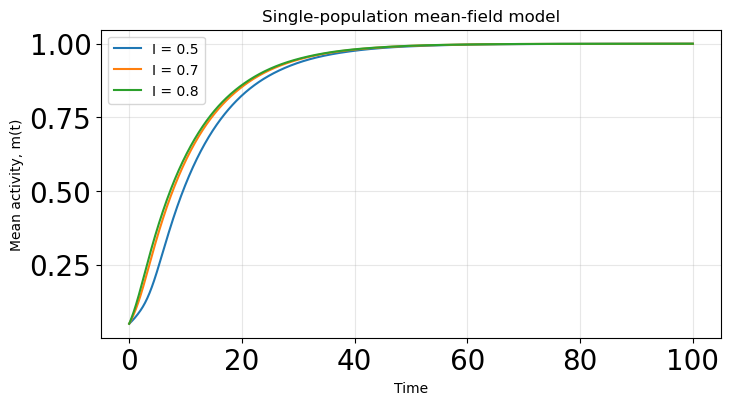

In [88]:
tau = 10.0
J = 4.0
a = 4.0
theta = 1.0

I_values = [0.5, 0.7, 0.8]

t_eval = np.linspace(0, 100, 1000)
m0 = [0.05]

plt.figure(figsize=(8, 4))

for I in I_values:
    sol = solve_ivp(
        mean_field_rhs,
        t_span=[0, 100],
        y0=m0,
        t_eval=t_eval,
        args=(tau, J, I, a, theta)
    )

    plt.plot(sol.t, sol.y[0], label=f"I = {I}")

plt.xlabel("Time")
plt.ylabel("Mean activity, m(t)")
plt.title("Single-population mean-field model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## compare full network with mean field

In [89]:
def full_rate_network_rhs(t, r, tau, J, I, a, theta):
    """
    Full all-to-all rate network.

    tau dr_i/dt = -r_i + sigma((J/N) sum_j r_j + I)
    """
    N = len(r)

    mean_activity = np.mean(r)

    input_to_each_neuron = J * mean_activity + I

    drdt = (-r + sigma(input_to_each_neuron, a=a, theta=theta)) / tau

    return drdt

In [90]:
rng = np.random.default_rng(42)

N = 200

tau = 10.0
J = 4.0
I = -0.5
a = 4.0
theta = 1.0

T = 100
t_eval = np.linspace(0, T, 1000)

# Initial conditions
r0 = rng.uniform(0, 0.2, size=N)
m0 = [np.mean(r0)]

# Full network simulation
sol_net = solve_ivp(
    full_rate_network_rhs,
    t_span=[0, T],
    y0=r0,
    t_eval=t_eval,
    args=(tau, J, I, a, theta)
)

# Mean-field simulation
sol_mf = solve_ivp(
    mean_field_rhs,
    t_span=[0, T],
    y0=m0,
    t_eval=t_eval,
    args=(tau, J, I, a, theta)
)

mean_network_activity = sol_net.y.mean(axis=0)
mean_field_activity = sol_mf.y[0]

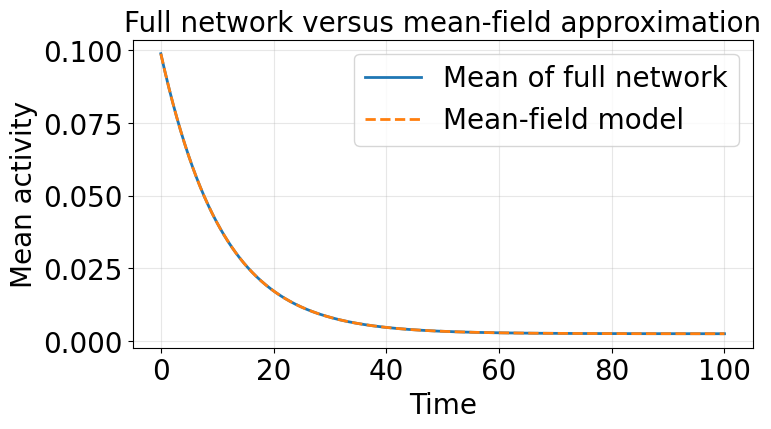

In [91]:
plt.figure(figsize=(8, 4))

plt.plot(
    sol_net.t,
    mean_network_activity,
    label="Mean of full network",
    linewidth=2
)

plt.plot(
    sol_mf.t,
    mean_field_activity,
    "--",
    label="Mean-field model",
    linewidth=2
)

plt.xlabel("Time", fontsize=sz)
plt.ylabel("Mean activity", fontsize=sz)
plt.title("Full network versus mean-field approximation", fontsize=sz)
plt.legend(fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

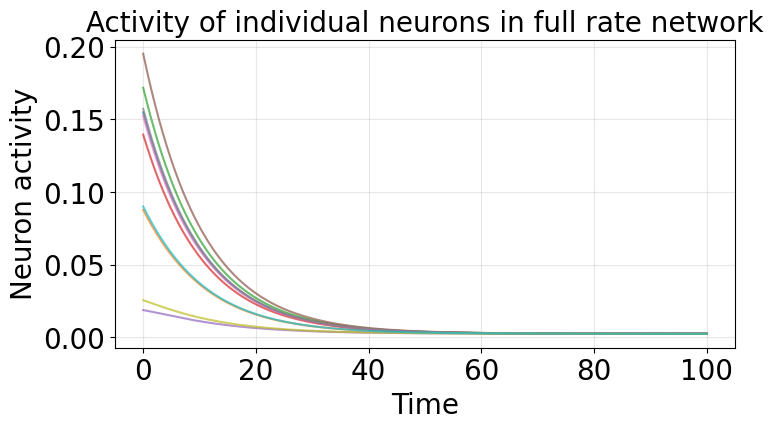

In [211]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.plot(sol_net.t, sol_net.y[i], alpha=0.7)

plt.xlabel("Time", fontsize=sz)
plt.ylabel("Neuron activity", fontsize=sz)
plt.title("Activity of individual neurons in full rate network", fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Two population E/I mean-field model

In [92]:
def ei_mean_field_rhs(t, z, params):
    """
    Two-population E/I mean-field model.

    z[0] = m_E
    z[1] = m_I
    """
    mE, mI = z

    tau_E = params["tau_E"]
    tau_I = params["tau_I"]

    J_EE = params["J_EE"]
    J_EI = params["J_EI"]
    J_IE = params["J_IE"]
    J_II = params["J_II"]

    I_E = params["I_E"]
    I_I = params["I_I"]

    a = params["a"]
    theta = params["theta"]

    input_E = J_EE * mE - J_EI * mI + I_E
    input_I = J_IE * mE - J_II * mI + I_I

    dmE = (-mE + sigma(input_E, a=a, theta=theta)) / tau_E
    dmI = (-mI + sigma(input_I, a=a, theta=theta)) / tau_I

    return [dmE, dmI]

In [93]:
params = {
    "tau_E": 10.0,
    "tau_I": 20.0,
    "J_EE": 10.0,
    "J_EI": 12.0,
    "J_IE": 10.0,
    "J_II": 2.0,
    "I_E": 0.5,
    "I_I": 0.0,
    "a": 3.0,
    "theta": 1.0
}

z0 = [0.1, 0.1]
t_eval = np.linspace(0, 300, 2000)

sol = solve_ivp(
    ei_mean_field_rhs,
    t_span=[0, 300],
    y0=z0,
    t_eval=t_eval,
    args=(params,)
)

mE = sol.y[0]
mI = sol.y[1]

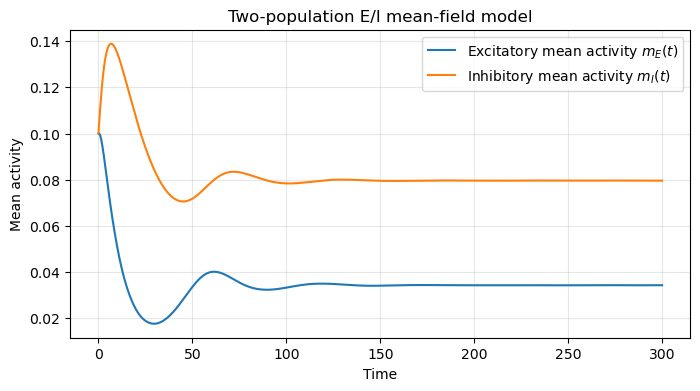

In [214]:
plt.figure(figsize=(8, 4))

plt.plot(sol.t, mE, label=r"Excitatory mean activity $m_E(t)$")
plt.plot(sol.t, mI, label=r"Inhibitory mean activity $m_I(t)$")

plt.xlabel("Time")
plt.ylabel("Mean activity")
plt.title("Two-population E/I mean-field model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [94]:
mE_vals = np.linspace(0, 1, 150)
mI_vals = np.linspace(0, 1, 150)

ME, MI = np.meshgrid(mE_vals, mI_vals)

dME = np.zeros_like(ME)
dMI = np.zeros_like(MI)

for i in range(ME.shape[0]):
    for j in range(ME.shape[1]):
        dE, dI = ei_mean_field_rhs(0, [ME[i, j], MI[i, j]], params)
        dME[i, j] = dE
        dMI[i, j] = dI

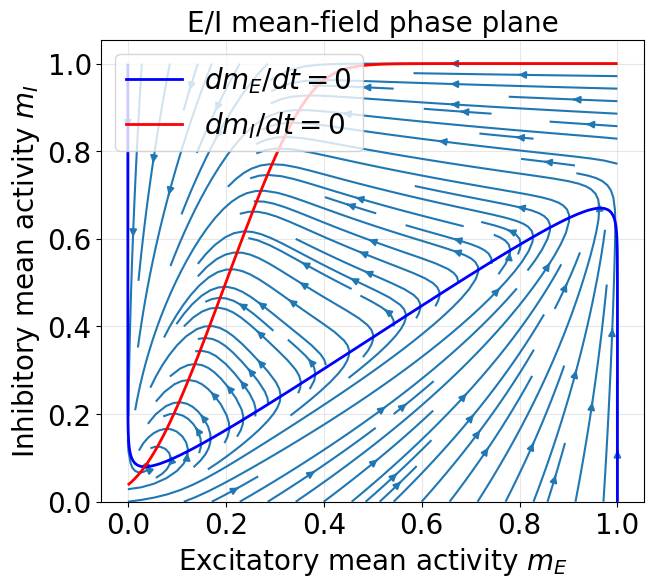

In [95]:
plt.figure(figsize=(7, 6))

plt.streamplot(
    ME,
    MI,
    dME,
    dMI,
    density=1.2,
    arrowsize=1
)

plt.contour(
    ME,
    MI,
    dME,
    levels=[0],
    colors="blue",
    linewidths=2
)

plt.contour(
    ME,
    MI,
    dMI,
    levels=[0],
    colors="red",
    linewidths=2
)

plt.xlabel(r"Excitatory mean activity $m_E$", fontsize=sz)
plt.ylabel(r"Inhibitory mean activity $m_I$", fontsize=sz)
plt.title("E/I mean-field phase plane", fontsize=sz)

plt.plot([], [], color="blue", linewidth=2, label=r"$dm_E/dt=0$")
plt.plot([], [], color="red", linewidth=2, label=r"$dm_I/dt=0$")

plt.legend(fontsize=sz)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=sz)

## Kuramoto's model

In [220]:
def kuramoto_rhs(t, theta, omega, K):
    """
    Kuramoto model with all-to-all coupling.

    theta : phases of all oscillators, shape (N,)
    omega : natural frequencies, shape (N,)
    K     : coupling strength
    """
    N = len(theta)

    # theta_j - theta_i for all pairs i, j
    phase_differences = theta[None, :] - theta[:, None]

    coupling = (K / N) * np.sum(np.sin(phase_differences), axis=1)

    dtheta_dt = omega + coupling

    return dtheta_dt

In [221]:
def order_parameter(theta):
    """
    Compute Kuramoto order parameter.

    Returns:
        R   : synchrony strength
        psi : average phase
    """
    z = np.mean(np.exp(1j * theta))

    R = np.abs(z)
    psi = np.angle(z)

    return R, psi

In [222]:
rng = np.random.default_rng(42)

N = 50

# Natural frequencies
omega = rng.normal(loc=1.0, scale=0.2, size=N)

# Initial phases uniformly distributed around the circle
theta0 = rng.uniform(0, 2*np.pi, size=N)

# Time
t_eval = np.linspace(0, 50, 1000)

coupling_values = [0.2, 3.0]
solutions = {}

for K in coupling_values:
    sol = solve_ivp(
        kuramoto_rhs,
        t_span=[0, 50],
        y0=theta0,
        t_eval=t_eval,
        args=(omega, K)
    )

    solutions[K] = sol

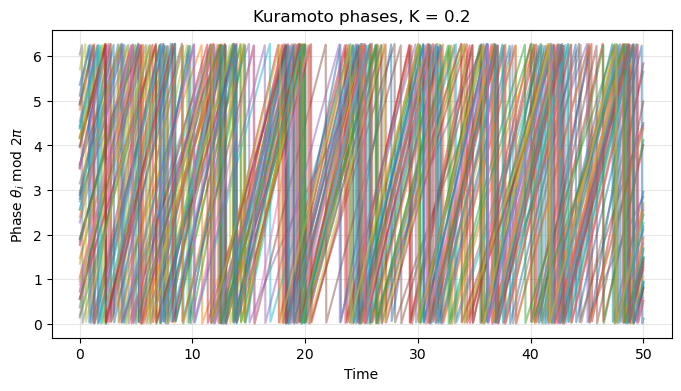

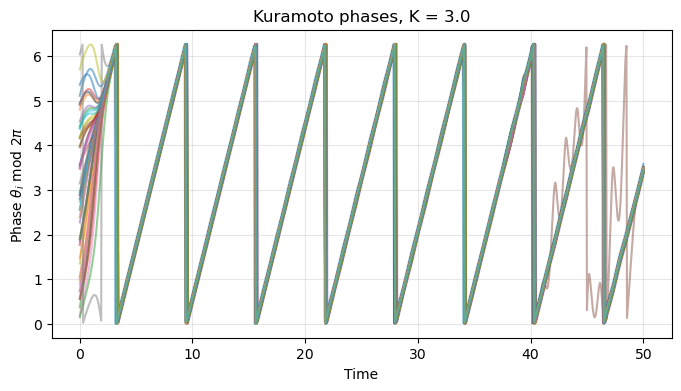

In [223]:
for K, sol in solutions.items():
    theta_t = sol.y

    plt.figure(figsize=(8, 4))

    for i in range(N):
        plt.plot(sol.t, np.mod(theta_t[i], 2*np.pi), alpha=0.5)

    plt.xlabel("Time")
    plt.ylabel(r"Phase $\theta_i$ mod $2\pi$")
    plt.title(f"Kuramoto phases, K = {K}")
    plt.grid(True, alpha=0.3)
    plt.show()

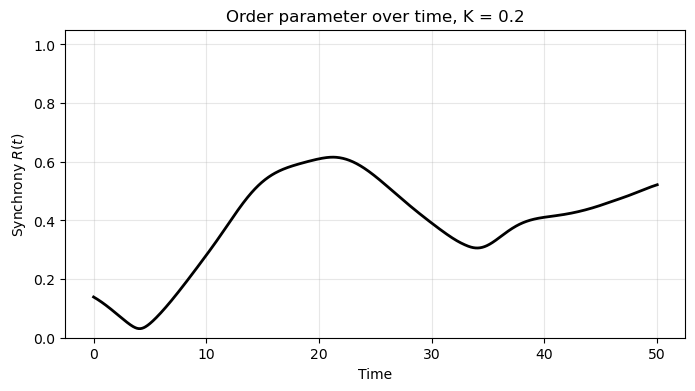

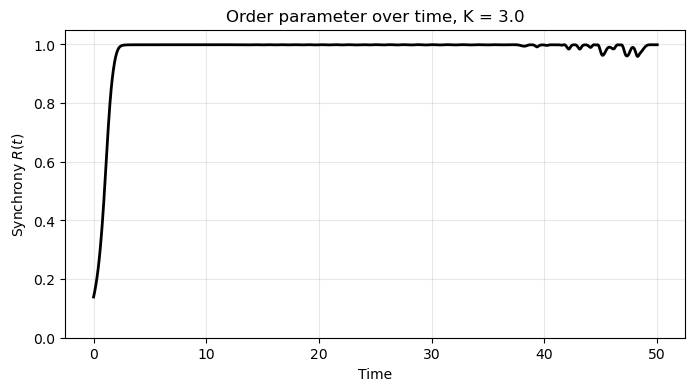

In [224]:
for K, sol in solutions.items():
    theta_t = sol.y

    R_values = []

    for k in range(theta_t.shape[1]):
        R, psi = order_parameter(theta_t[:, k])
        R_values.append(R)

    R_values = np.array(R_values)

    plt.figure(figsize=(8, 4))
    plt.plot(sol.t, R_values, color="black", linewidth=2)

    plt.xlabel("Time")
    plt.ylabel(r"Synchrony $R(t)$")
    plt.title(f"Order parameter over time, K = {K}")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.show()

In [225]:
def plot_phases_on_circle(theta, title=None):
    """
    Plot oscillator phases on the unit circle.
    """
    R, psi = order_parameter(theta)

    x = np.cos(theta)
    y = np.sin(theta)

    circle = np.linspace(0, 2*np.pi, 400)

    plt.figure(figsize=(5, 5))

    # Unit circle
    plt.plot(np.cos(circle), np.sin(circle), color="black", linewidth=1)

    # Oscillator phases
    plt.scatter(x, y, s=60, color="black")

    # Mean-field vector
    plt.arrow(
        0,
        0,
        R * np.cos(psi),
        R * np.sin(psi),
        width=0.02,
        length_includes_head=True,
        color="red"
    )

    plt.text(
        0.05,
        -1.25,
        rf"$R = {R:.2f}$",
        fontsize=14
    )

    plt.axis("equal")
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()

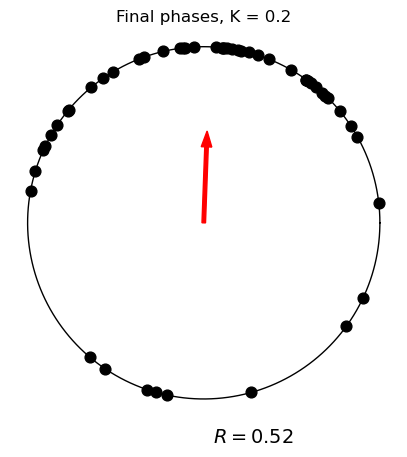

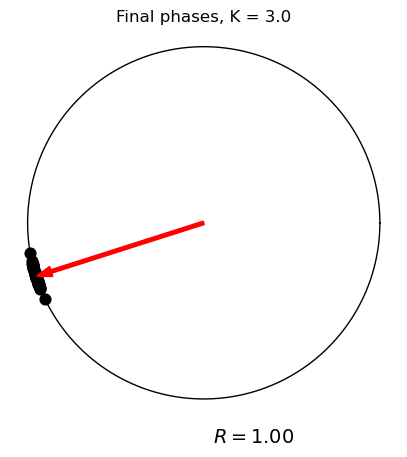

In [226]:
for K, sol in solutions.items():
    theta_final = sol.y[:, -1]

    plot_phases_on_circle(
        theta_final,
        title=f"Final phases, K = {K}"
    )

## Mean-field form in the code

In [227]:
def kuramoto_mean_field_rhs(t, theta, omega, K):
    """
    Kuramoto model written using the global mean field.

    dtheta_i/dt = omega_i + K R sin(psi - theta_i)
    """
    R, psi = order_parameter(theta)

    dtheta_dt = omega + K * R * np.sin(psi - theta)

    return dtheta_dt

In [228]:
theta_example = theta0.copy()
K = 2.0

rhs_pairwise = kuramoto_rhs(0, theta_example, omega, K)
rhs_meanfield = kuramoto_mean_field_rhs(0, theta_example, omega, K)

print("Maximum difference:")
print(np.max(np.abs(rhs_pairwise - rhs_meanfield)))

Maximum difference:
2.220446049250313e-16
